In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
df_multiSubject_binary = pd.read_csv('experiment/results/data/multiSubject_binary.csv')
df_multiSubject_discrete = pd.read_csv('experiment/results/data/multiSubject_discrete.csv')
df_finetuning_binary = pd.read_csv('experiment/results/data/finetuning_binary.csv')
df_finetuning_discrete = pd.read_csv('experiment/results/data/finetuning_discrete.csv')
df_multiSubject_binaryCV = pd.read_csv('experiment/results/data/multiSubject_binaryCV.csv')
df_multiSubject_discreteCV = pd.read_csv('experiment/results/data/multiSubject_discreteCV.csv')

df_finetuning_regressor = pd.read_csv('experiment/results/data/finetuning_regression.csv')
df_multiSubject_regressorCV = pd.read_csv('experiment/results/data/multiSubject_regressionCV.csv')
df_multiSubject_regressor = pd.read_csv('experiment/results/data/multiSubject_regression.csv')
df_nasatlx = pd.read_csv("experiment/results/NASATLX_Averages.csv")

def add_condition_names(df):

    condition_map = {
        "FW": ("Flappy Passive", "Flappy", "Passive"),
        "LW": ("Lunar Passive", "Lunar", "Passive"),
        "FP": ("Flappy Active", "Flappy", "Active"),
        "LP": ("Lunar Active", "Lunar", "Active"),
        "RP": ("Robot Active", "Robot", "Active"),
        "RW": ("Robot Passive", "Robot", "Passive"),
        "FW, LW, RW": ("All Passive", None, "Passive"),
        "FP, LP, RP": ("All Active", None, "Active")
    }


    conditions, games, tasks = [], [], []
    for condition in df["TrainConditions"]:
        if len(str(condition)) > 4 and len(str(condition)) < 7:
            condition_str = str(condition).strip().replace("'", "").replace("[", "").replace("]", "")
        else: condition_str = str(condition)
        if condition_str in condition_map:
            cond, game, task = condition_map[condition_str]
            conditions.append(cond)
            games.append(game)
            tasks.append(task)
        else:
            conditions.append(condition_str)
            games.append(None)
            tasks.append(None)

    df["Conditions"] = conditions
    df["Game"] = games
    df["Task"] = tasks

    return df

df_multiSubject_binary = add_condition_names(df_multiSubject_binary)
df_multiSubject_discrete = add_condition_names(df_multiSubject_discrete)
df_multiSubject_binaryCV = add_condition_names(df_multiSubject_binaryCV)
df_multiSubject_discreteCV = add_condition_names(df_multiSubject_discreteCV)
df_finetuning_binary = add_condition_names(df_finetuning_binary)
df_finetuning_discrete = add_condition_names(df_finetuning_discrete)
df_finetuning_regression = add_condition_names(df_finetuning_regressor)
df_multiSubject_regression = add_condition_names(df_multiSubject_regressor)
df_multiSubject_regressionCV = add_condition_names(df_multiSubject_regressorCV)



### NASA TLX Scores

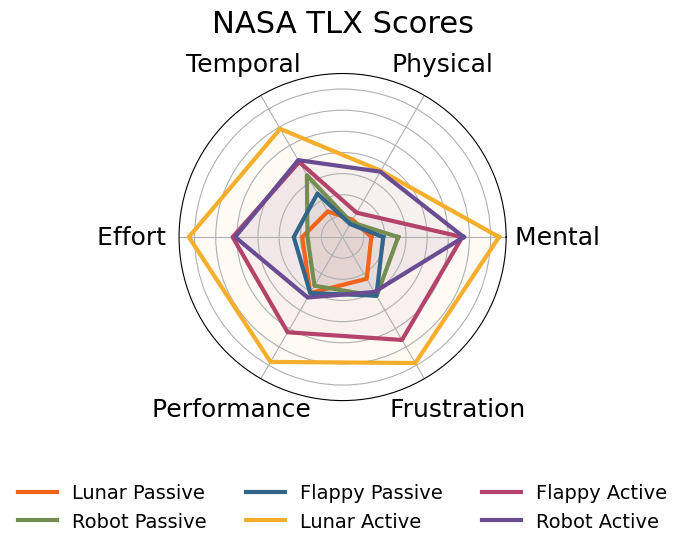

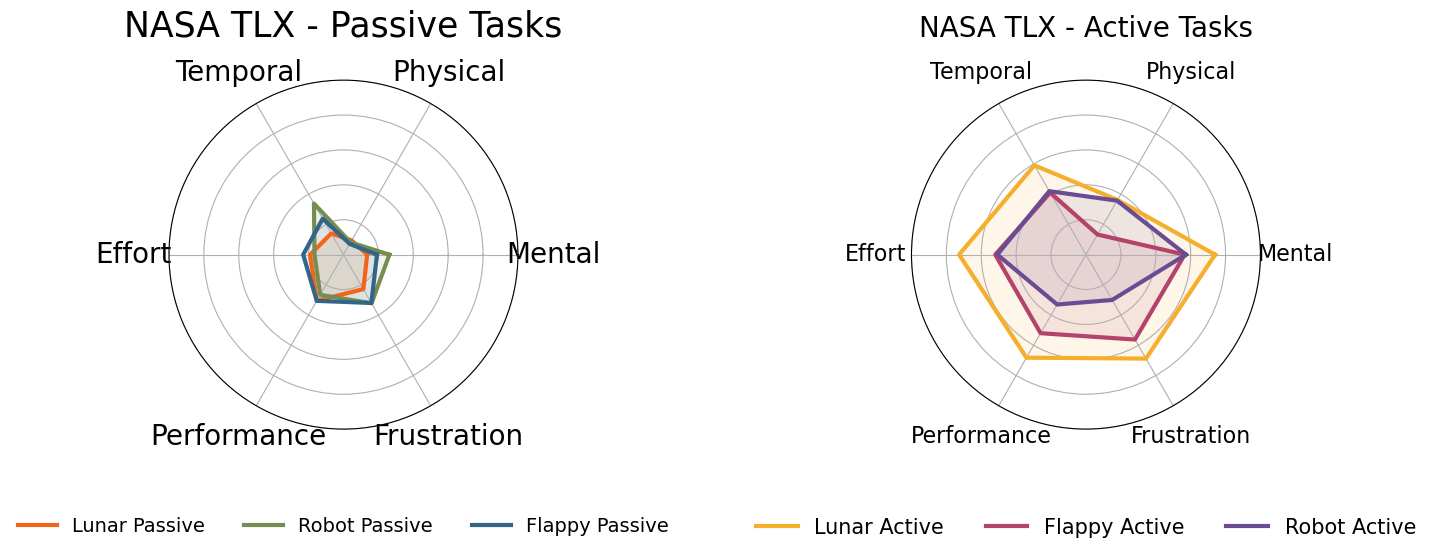

In [4]:
num_vars=6
palette2 = ["#f26419", "#758e4f", "#33658a", "#f6ae2d", "#b4436c", "#6a4c93"]


categories = ["Mental", "Physical", "Temporal", "Effort", "Performance", "Frustration"]
categories2 = ["    Mental", "Physical", "Temporal", "Effort   ", "Performance   ", "    Frustration"]

#angle for each category
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# radar chart
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

# Plot
for i, row in df_nasatlx.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    ax.plot(angles, values, label=row['Unnamed: 0'], color=palette2[i % len(palette2)], linewidth=3)
    ax.fill(angles, values, color=palette2[i % len(palette2)], alpha=0.05)

ax.set_title('NASA TLX Scores', size=22, color='black', y=1.1)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories2, size=18, color='black')
ax.tick_params(axis='x', which='major', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=14, ncol=3, frameon=False)

plt.tight_layout()
plt.show()

df_nasatlx_passive = df_nasatlx[df_nasatlx['Unnamed: 0'].str.contains('Passive')]
df_nasatlx_active = df_nasatlx[df_nasatlx['Unnamed: 0'].str.contains('Active')]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), subplot_kw=dict(polar=True))

for i, row in df_nasatlx_passive.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    axes[0].plot(angles, values, label=row['Unnamed: 0'], color=palette2[i % len(palette2)], linewidth=3)
    axes[0].fill(angles, values, color=palette2[i % len(palette2)], alpha=0.1)

axes[0].set_title('NASA TLX - Passive Tasks', size=25, color='black', y=1.1)
axes[0].set_yticklabels([])
axes[0].set_xticks(angles[:-1])
axes[0].set_xticklabels(categories, size=20, color='black')
axes[0].tick_params(axis='x', which='major', pad=15)
axes[0].set_ylim(0, 100)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=14, ncol=3, frameon=False)

for i, row in df_nasatlx_active.iterrows():
    values = row[categories].tolist()
    values += values[:1]
    axes[1].plot(angles, values, label=row['Unnamed: 0'], color=palette2[i % len(palette2)], linewidth=3)
    axes[1].fill(angles, values, color=palette2[i % len(palette2)], alpha=0.1)

axes[1].set_title('NASA TLX - Active Tasks', size=20, color='black', y=1.1)
axes[1].set_yticklabels([])
axes[1].set_xticks(angles[:-1])
axes[1].set_xticklabels(categories, size=16, color='black')
axes[1].tick_params(axis='x', which='major', pad=15)
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fontsize=15, ncol=3, frameon=False)

plt.tight_layout()
plt.show()

In [7]:
df_nasatlx.keys()

Index(['Unnamed: 0', 'Mental', 'Physical', 'Temporal', 'Effort', 'Performance',
       'Frustration'],
      dtype='object')

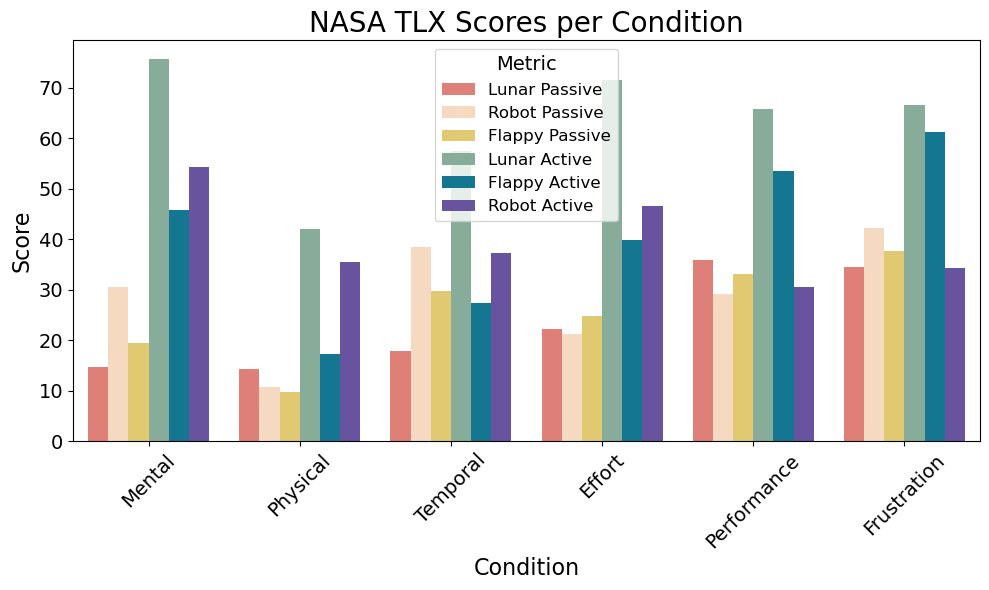

In [8]:
df_nasatlx
fig, ax = plt.subplots(figsize=(10, 6))

df_nasatlx_long = pd.melt(df_nasatlx, id_vars=['Unnamed: 0'], value_vars=['Mental', 'Physical', 'Temporal', 'Effort', 'Performance', 'Frustration'],
                          var_name='Metric', value_name='Score')
palette2 = ["#f07167", "#fed9b7", "#f4d35e", "#81b29a", "#0081a7", "#6247aa"]

sns.barplot(data=df_nasatlx_long, x='Metric', y='Score', hue='Unnamed: 0', palette=palette2, ax=ax)

ax.set_title('NASA TLX Scores per Condition', fontsize=20)
ax.set_xlabel('Condition', fontsize=16)
ax.set_ylabel('Score', fontsize=16)
ax.tick_params(axis='x', rotation=45, labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(title='Metric', title_fontsize='14', fontsize='12')

plt.tight_layout()
plt.show()

### Multi Subject Macro F1 Across Conditions

/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/3738327551.py:15: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/3738327551.py:24: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])


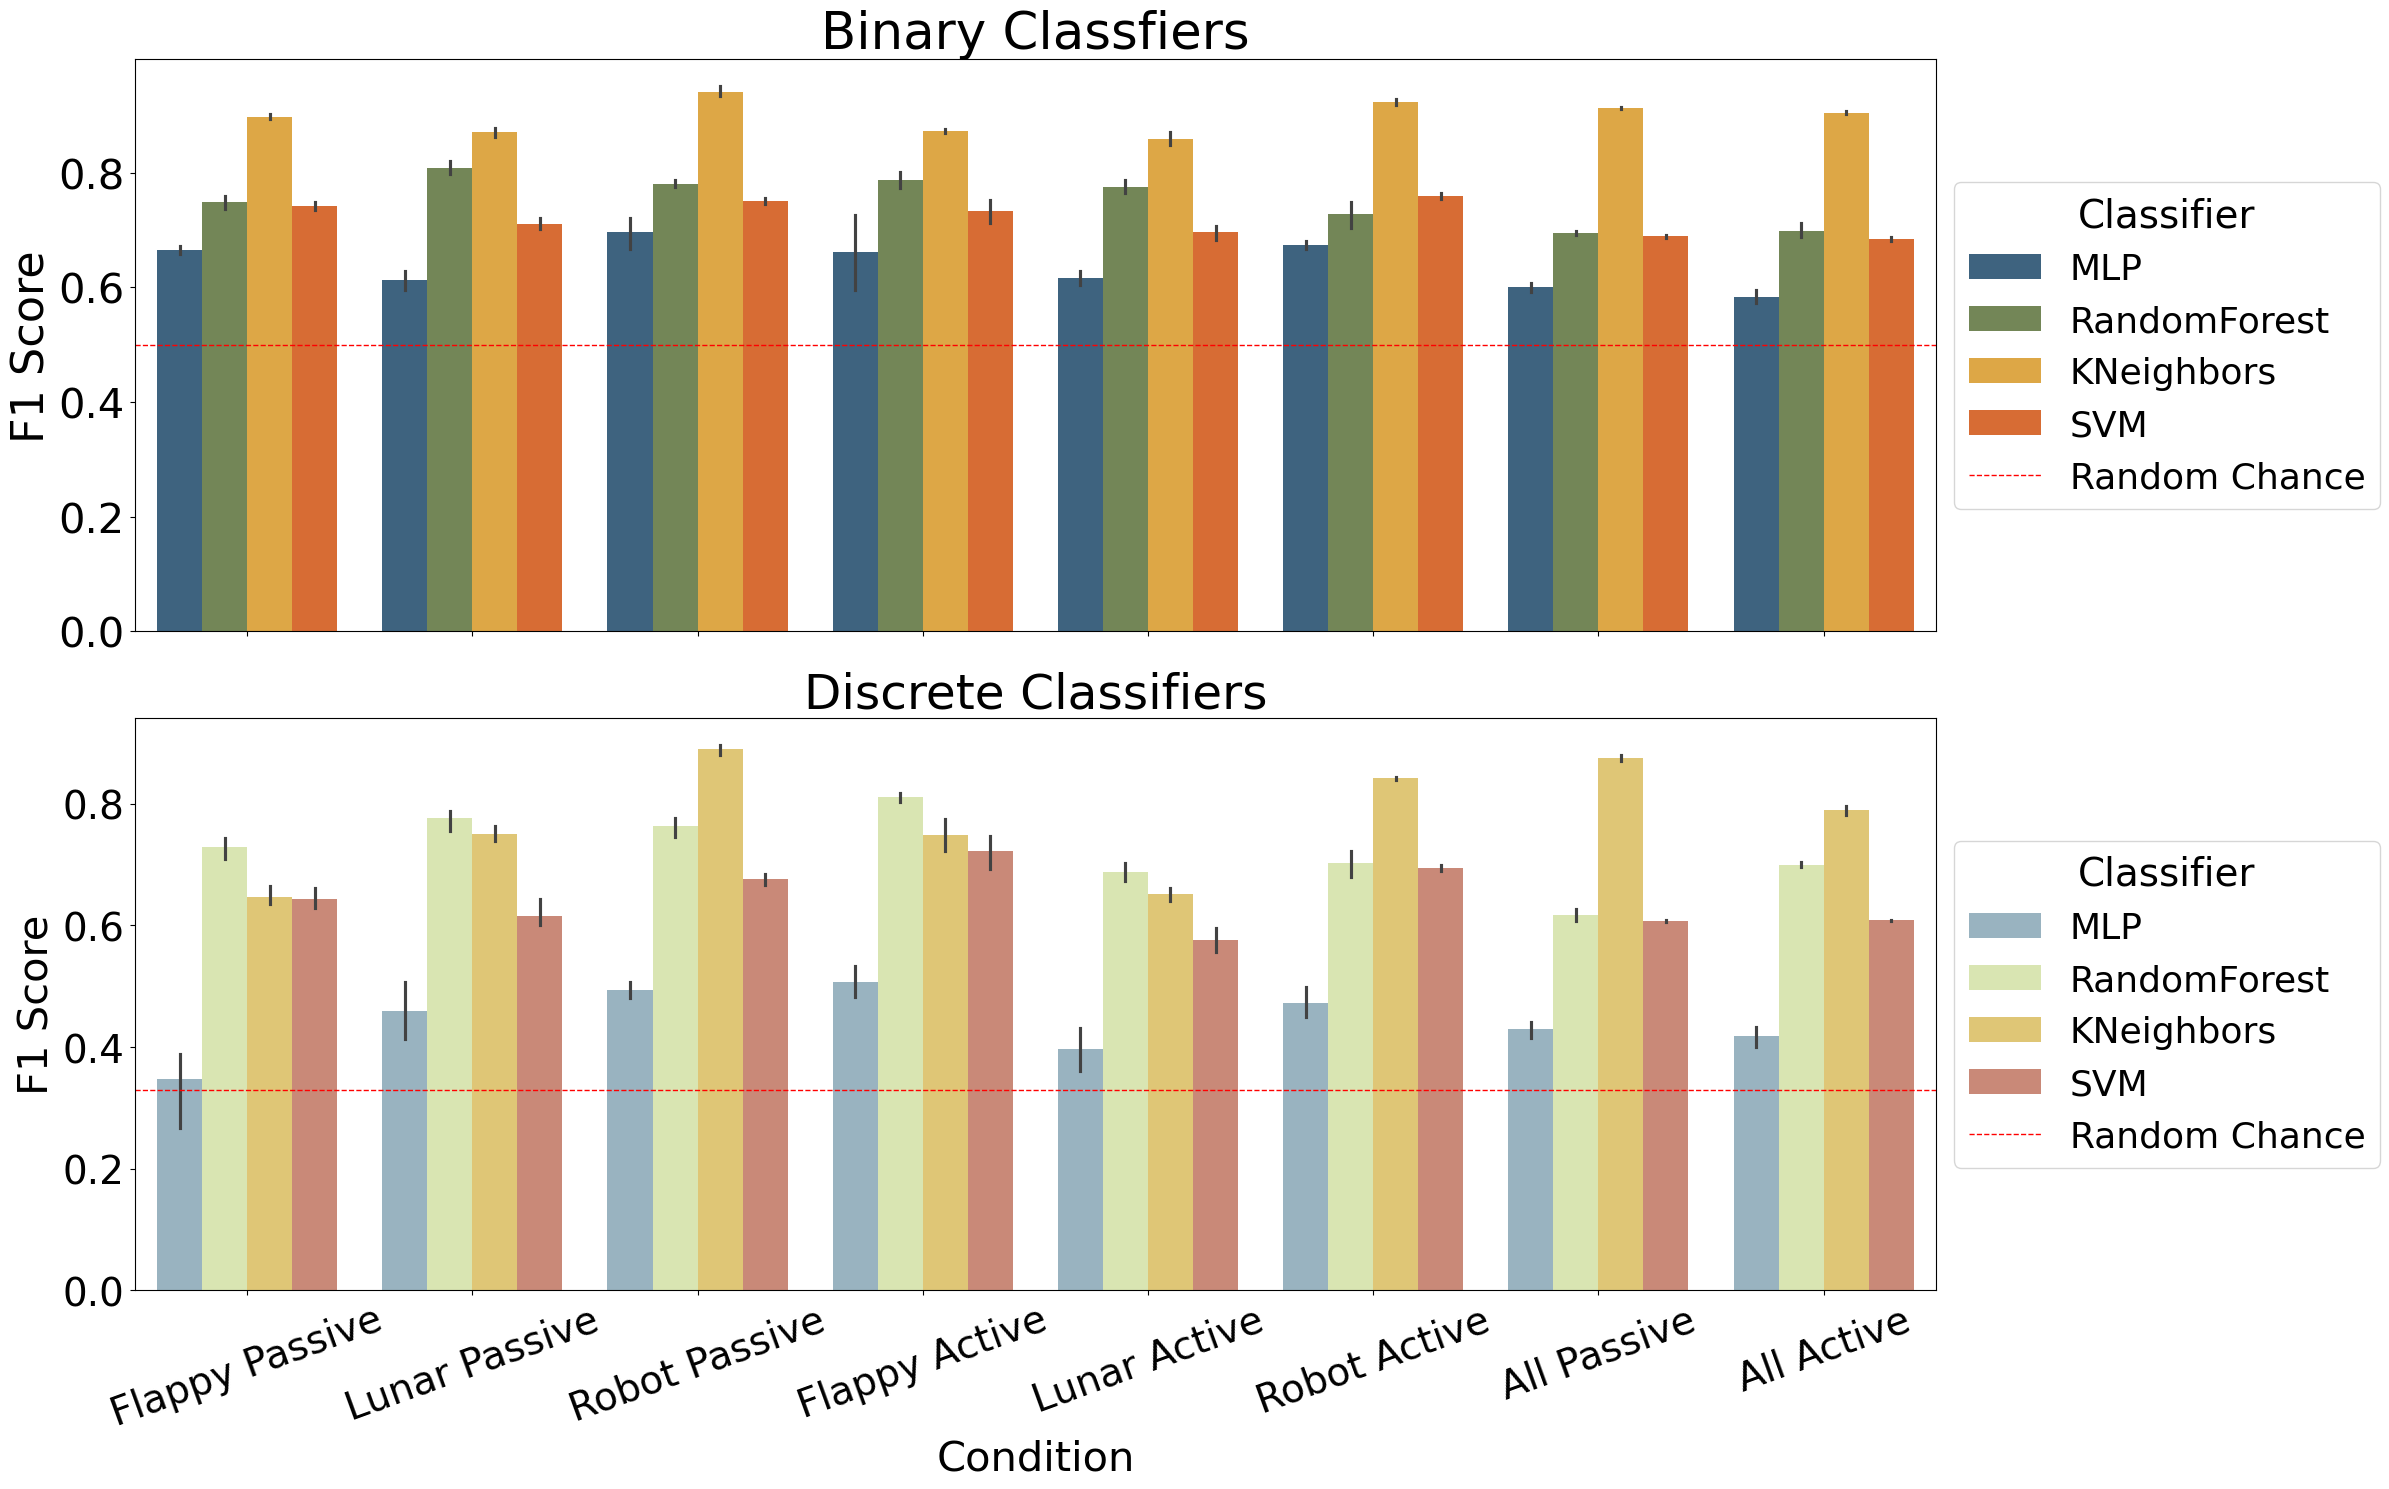

In [9]:
df_binary = df_multiSubject_binary
df_discrete = df_multiSubject_discrete

#melt
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]


fig, axes = plt.subplots(2, 1, figsize=(24, 15), sharex=True)

sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Classfiers', fontsize=37)
axes[0].set_xlabel('Condition', fontsize=32)
axes[0].set_ylabel('F1 Score', fontsize=32)
axes[0].tick_params(axis='x', rotation=20, labelsize=30)
axes[0].tick_params(axis='y', labelsize=30)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete Classifiers', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/1740886592.py:18: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[1])
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/1740886592.py:27: UserWarning: The palette list has more values (5) than needed (1), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[0])


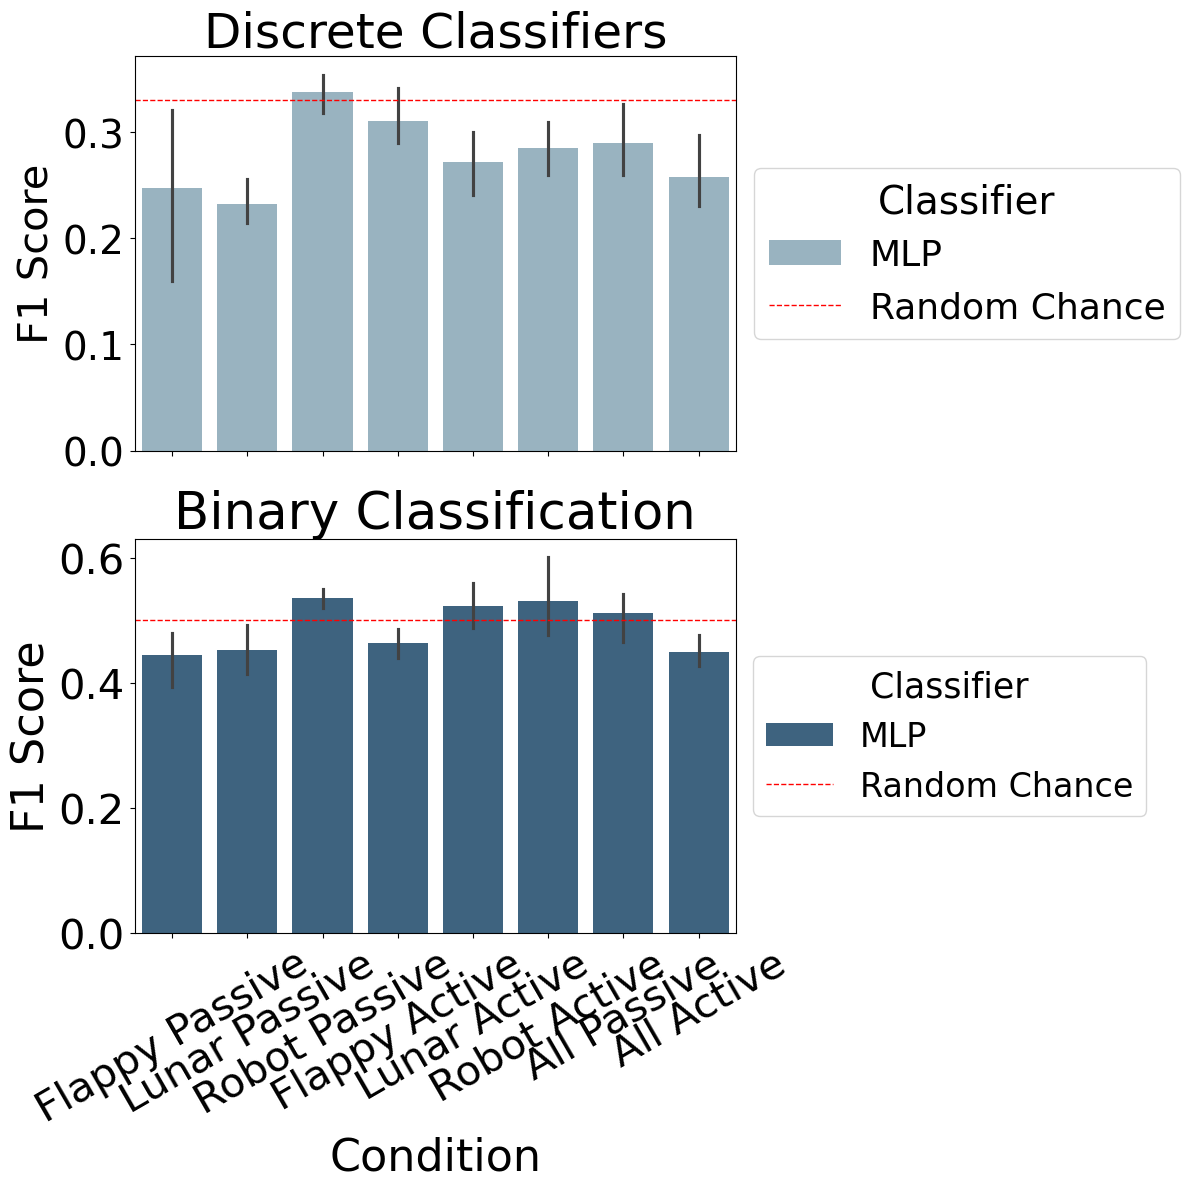

In [16]:
df_binary = df_multiSubject_binaryCV[df_multiSubject_binaryCV["Classifier"] == "MLP"]
df_discrete = df_multiSubject_discreteCV[df_multiSubject_discreteCV["Classifier"] == "MLP"]

# df_binary = df_binary[(df_binary["Conditions"] == "Robot Passive") | (df_binary["Conditions"] == "Flappy Passive")]
# df_discrete = df_discrete[(df_discrete["Conditions"] == "Robot Passive") | (df_discrete["Conditions"] == "Flappy Passive")]


#melt
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[1])
axes[1].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Binary Classification', fontsize=37)
axes[1].set_xlabel('Condition', fontsize=32)
axes[1].set_ylabel('F1 Score', fontsize=32)
axes[1].tick_params(axis='x', rotation=30, labelsize=30)
axes[1].tick_params(axis='y', labelsize=30)
axes[1].legend(title='Classifier', title_fontsize='25', fontsize='24', loc='center left', bbox_to_anchor=(1, 0.5))
    
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[0])
axes[0].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Discrete Classifiers', fontsize=35)
axes[0].set_xlabel('Condition', fontsize=30)
axes[0].set_ylabel('F1 Score', fontsize=30)
axes[0].tick_params(axis='x', rotation=30, labelsize=28)
axes[0].tick_params(axis='y', labelsize=28)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))


plt.tight_layout()
plt.show()


/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/1340344022.py:13: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_long_binary, x='Classifier', y='F1 Score', hue='Conditions', palette=palette, ax=axes[0])
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/1340344022.py:22: UserWarning: 
The palette list has fewer values (5) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_long_discrete, x='Classifier', y='F1 Score', hue='Conditions', palette=palette2, ax=axes[1])


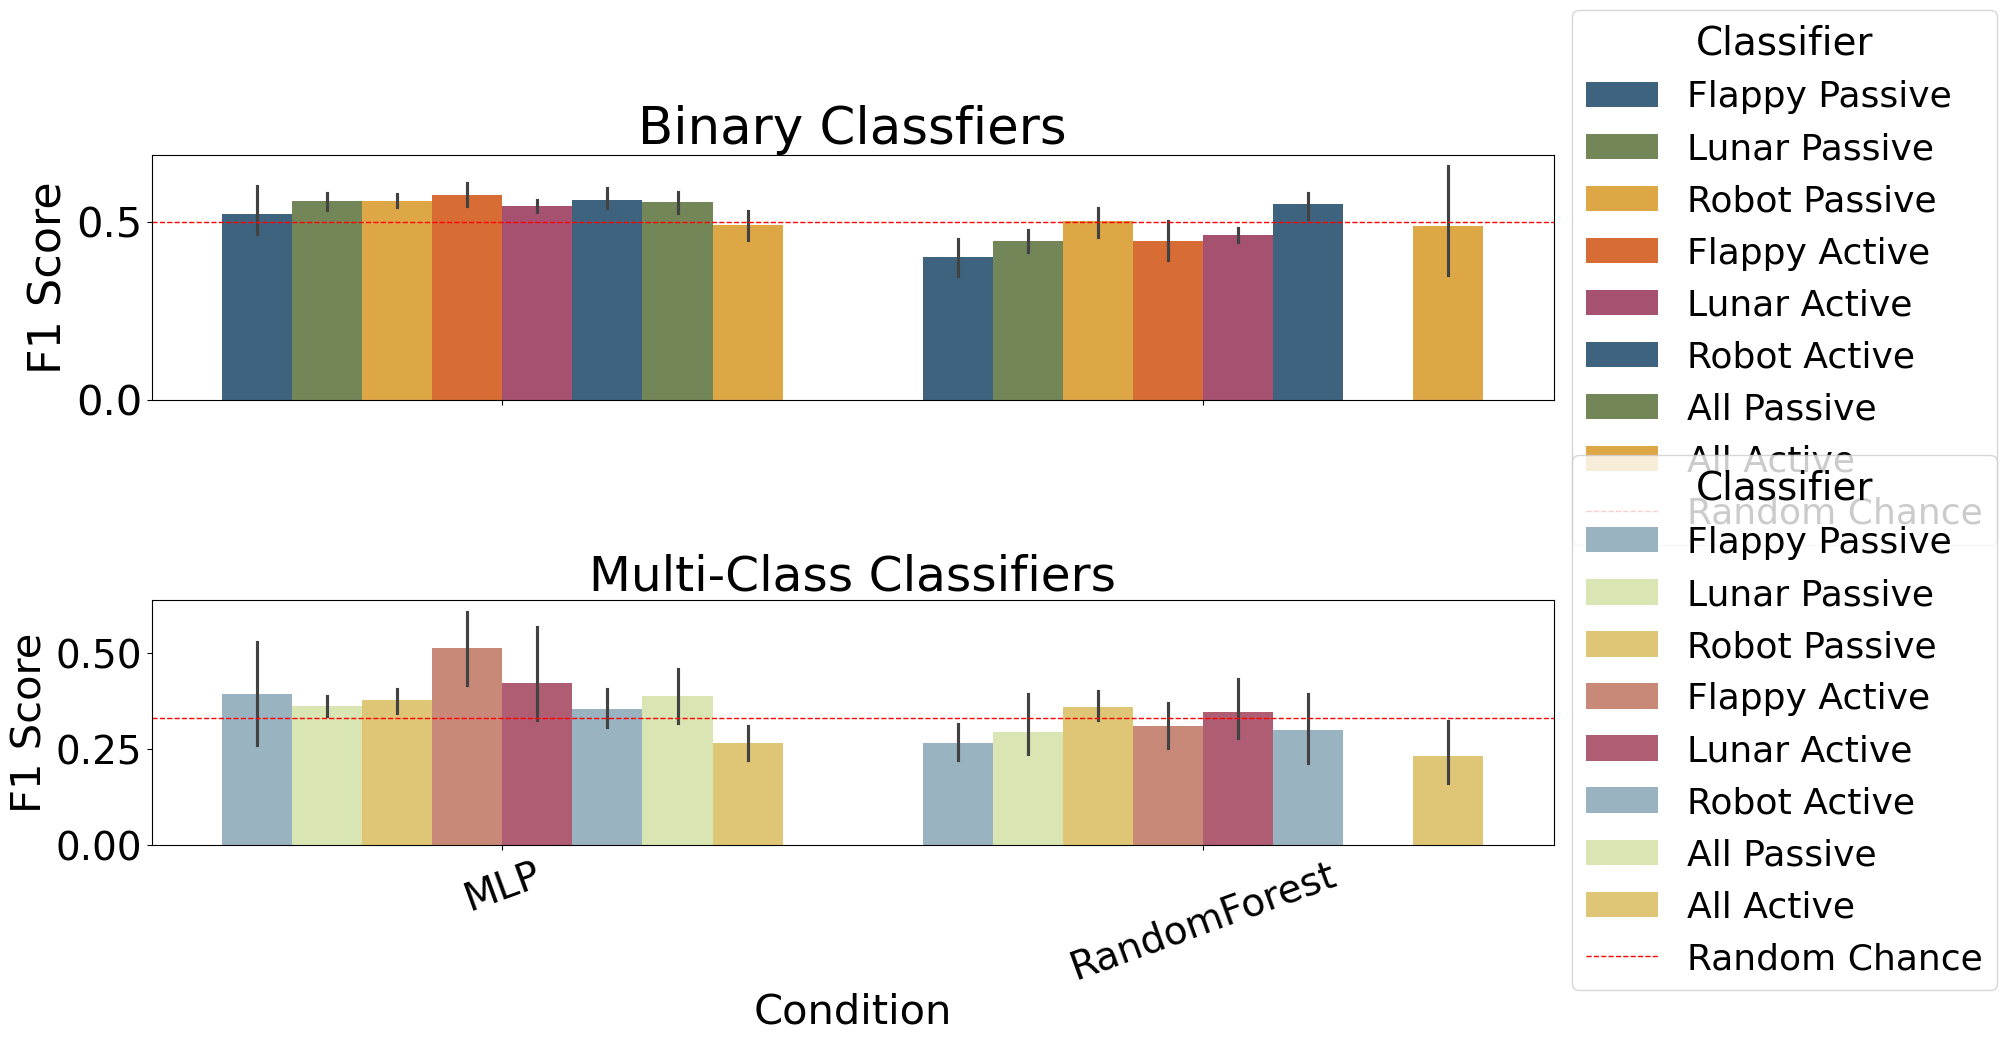

In [11]:
df_binary = df_finetuning_binary#[df_multiSubject_binary["TestParticipants"] == df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_finetuning_discrete#[df_multiSubject_discrete["TestParticipants"] == df_multiSubject_discrete["TrainParticipants"]]

df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

sns.barplot(data=df_long_binary, x='Classifier', y='F1 Score', hue='Conditions', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Classfiers', fontsize=37)
axes[0].set_xlabel('Condition', fontsize=32)
axes[0].set_ylabel('F1 Score', fontsize=32)
axes[0].tick_params(axis='x', rotation=20, labelsize=30)
axes[0].tick_params(axis='y', labelsize=30)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

sns.barplot(data=df_long_discrete, x='Classifier', y='F1 Score', hue='Conditions', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Multi-Class Classifiers', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()


/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/3674546601.py:13: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/3674546601.py:30: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])


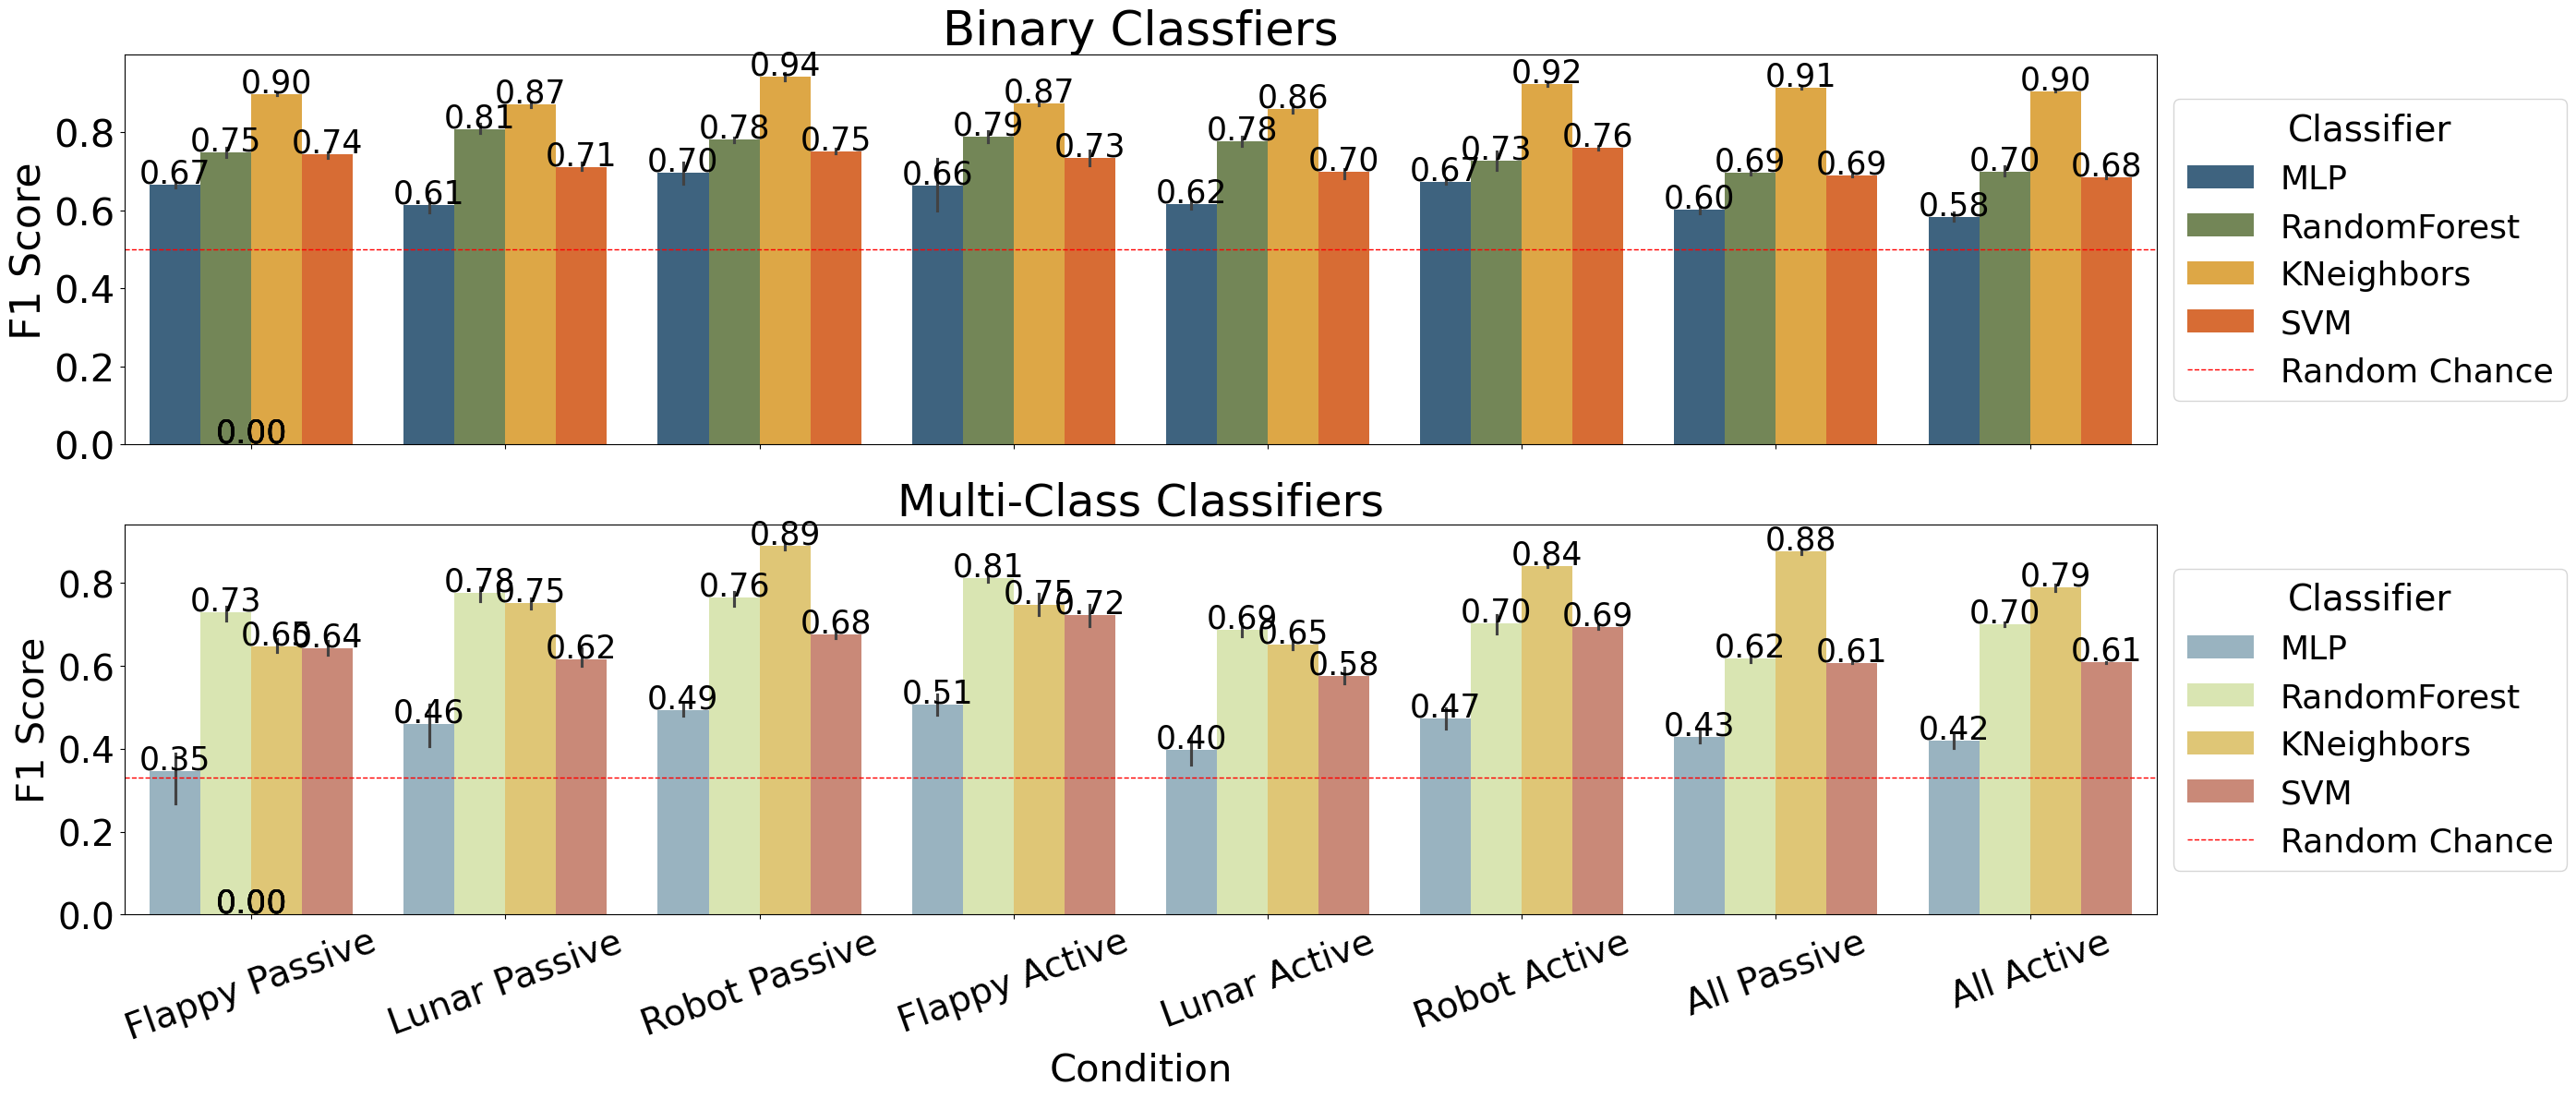

In [12]:
df_binary = df_multiSubject_binary#[df_multiSubject_binary["TestParticipants"] == df_multiSubject_binary["TrainParticipants"]]
df_discrete = df_multiSubject_discrete#df_multiSubject_discrete["TestParticipants"] == df_multiSubject_discrete["TrainParticipants"]]

df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Macro F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

fig, axes = plt.subplots(2, 1, figsize=(28, 12), sharex=True)

sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Classifier', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Classfiers', fontsize=37)
axes[0].set_xlabel('Condition', fontsize=32)
axes[0].set_ylabel('F1 Score', fontsize=32)
axes[0].tick_params(axis='x', rotation=20, labelsize=30)
axes[0].tick_params(axis='y', labelsize=30)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=25)
# Plot for discrete data
sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Classifier', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Multi-Class Classifiers', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=25)
plt.tight_layout()
plt.show()


Index(['Unnamed: 0', 'Regressor', 'MSE', 'R2', 'MAE', 'TrainParticipants',
       'TestParticipants', 'TrainConditions', 'TestConditions', 'Experiment',
       'RandomState', 'Conditions', 'Game', 'Task'],
      dtype='object')


/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/2843028253.py:15: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='R-Squared', hue='Regressor', palette=palette, ax=axes[0])
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/2843028253.py:29: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='R-Squared', hue='Regressor', palette=palette2, ax=axes[1])


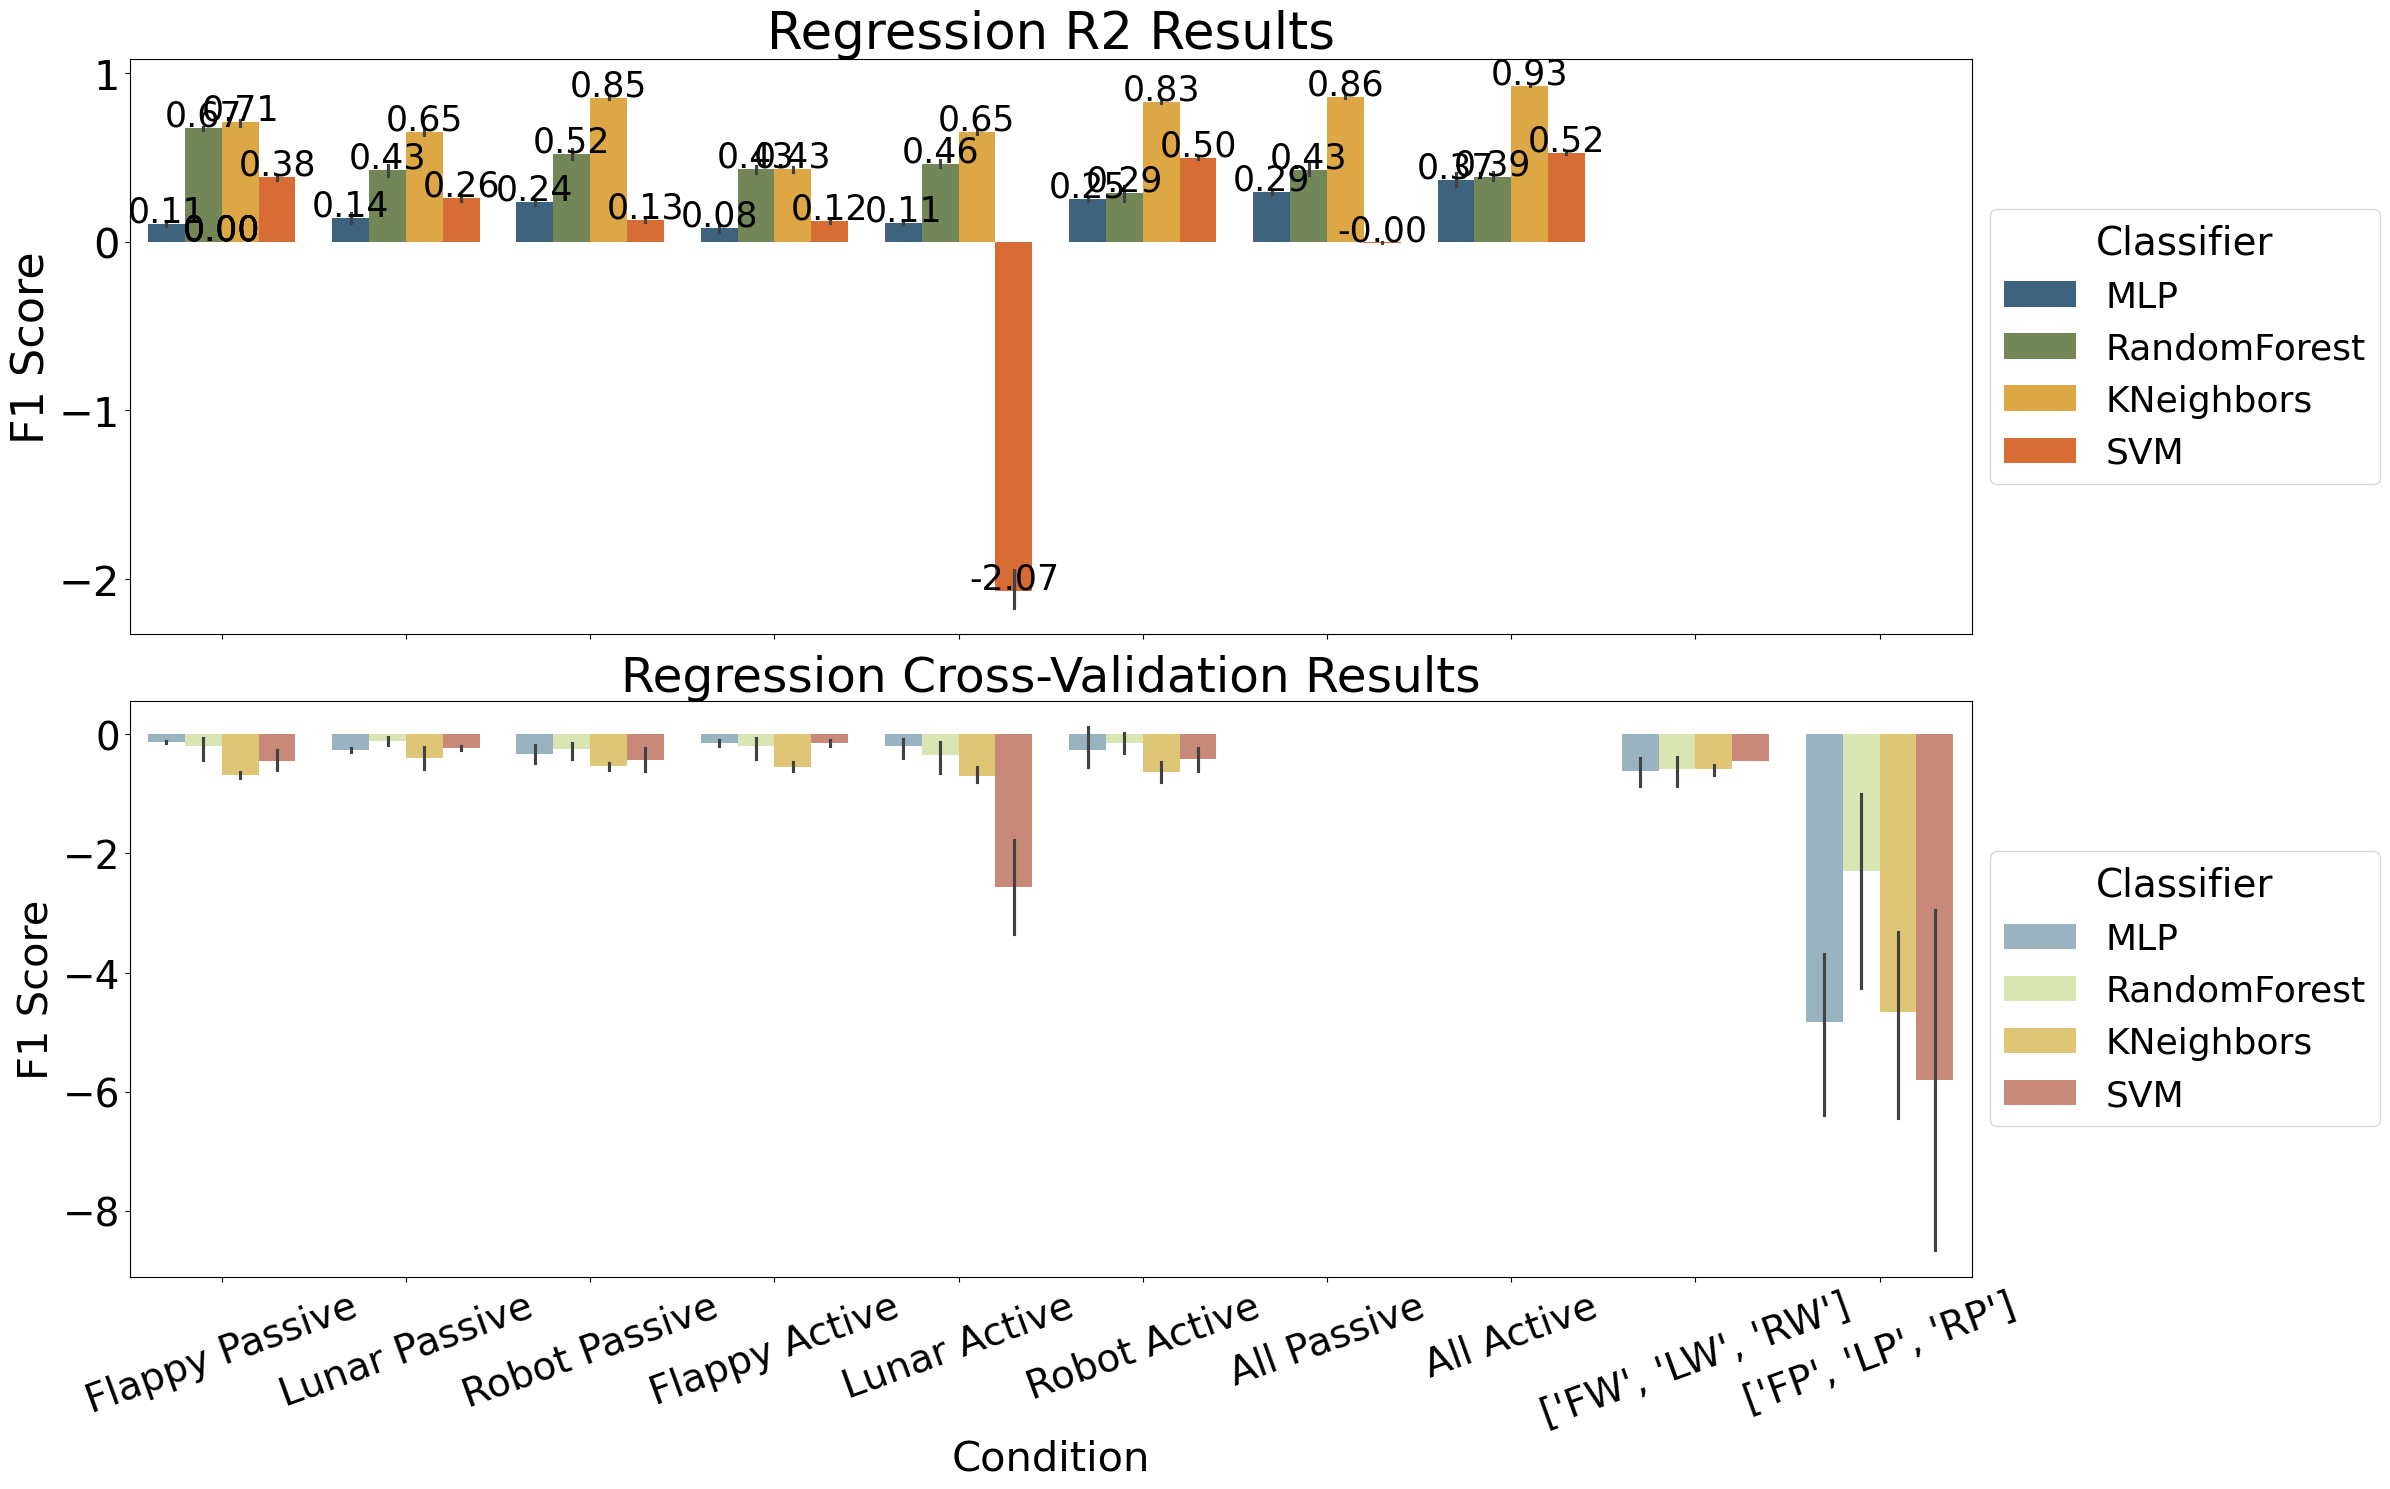

In [13]:
df_binary = df_multiSubject_regression
df_discrete = df_multiSubject_regressionCV

print(df_binary.keys())
df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Regressor'], value_vars=['R2'], 
                         var_name='Metric', value_name='R-Squared')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Regressor'], value_vars=['R2'], 
                           var_name='Metric', value_name='R-Squared')

palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

fig, axes = plt.subplots(2, 1, figsize=(24, 15), sharex=True)

sns.barplot(data=df_long_binary, x='Conditions', y='R-Squared', hue='Regressor', palette=palette, ax=axes[0])
axes[0].set_title('Regression R2 Results', fontsize=37)
axes[0].set_xlabel('Condition', fontsize=32)
axes[0].set_ylabel('F1 Score', fontsize=32)
axes[0].tick_params(axis='x', rotation=20, labelsize=30)
axes[0].tick_params(axis='y', labelsize=30)
axes[0].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.2f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=25)
sns.barplot(data=df_long_discrete, x='Conditions', y='R-Squared', hue='Regressor', palette=palette2, ax=axes[1])
axes[1].set_title('Regression Cross-Validation Results', fontsize=35)
axes[1].set_xlabel('Condition', fontsize=30)
axes[1].set_ylabel('F1 Score', fontsize=30)
axes[1].tick_params(axis='x', rotation=20, labelsize=28)
axes[1].tick_params(axis='y', labelsize=28)
axes[1].legend(title='Classifier', title_fontsize='28', fontsize='26', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/1731071880.py:13: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Metric', palette=palette, ax=axes[0])
/var/folders/qk/pvrkjyq14k50rmvbny7qk29w0000gn/T/ipykernel_63285/1731071880.py:22: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Metric', palette=palette2, ax=axes[1])


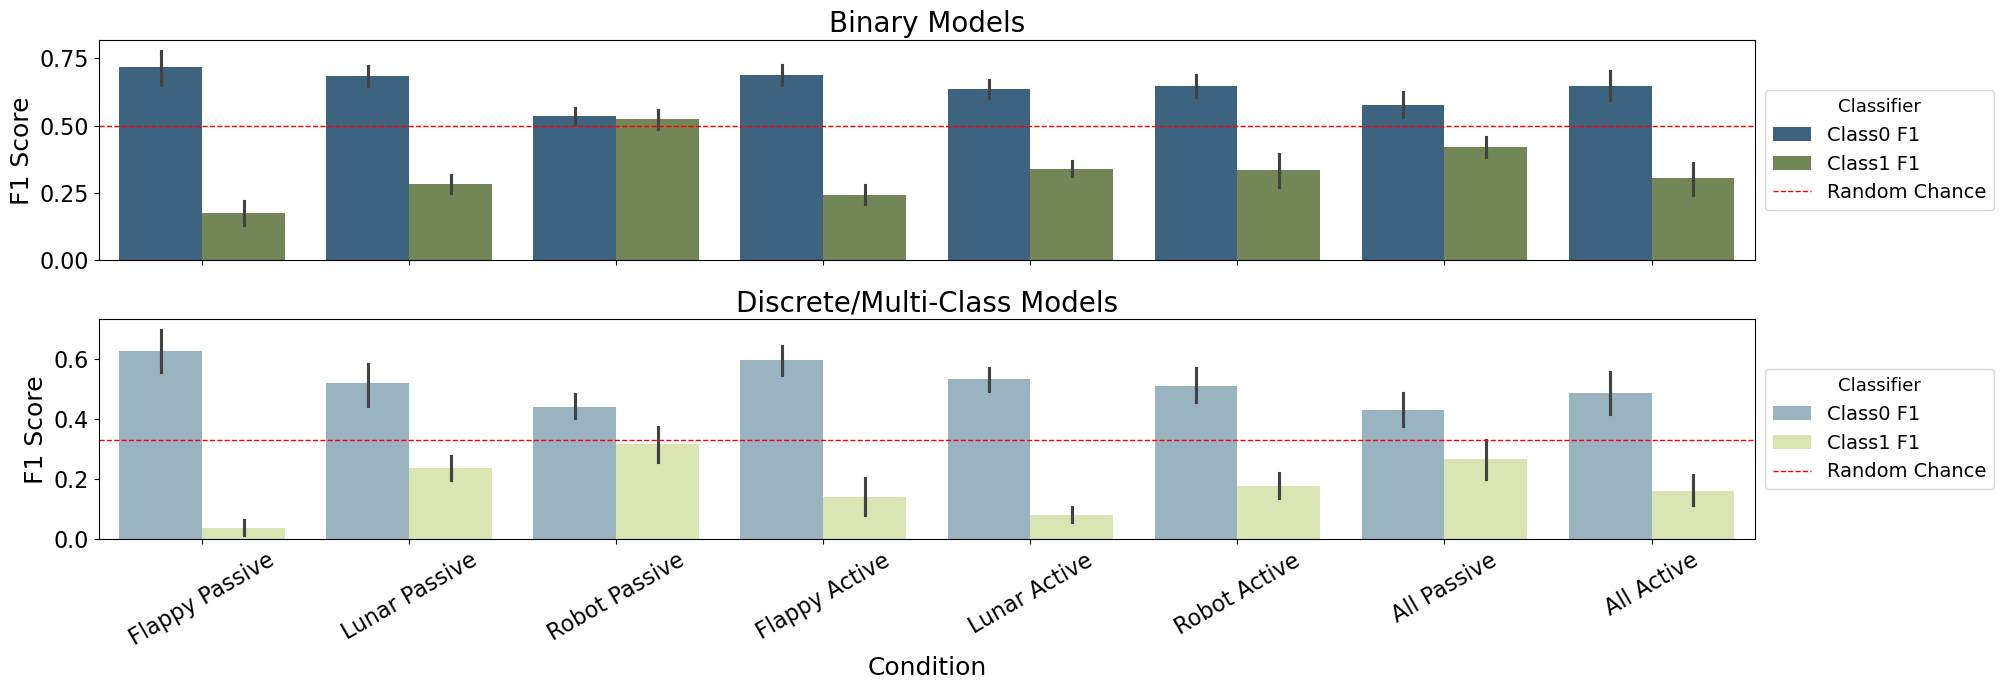

In [15]:
df_binary = df_multiSubject_binaryCV#df_singleSubject_binary[(df_singleSubject_binary["TestParticipants"] == df_singleSubject_binary["TrainParticipants"]) & (df_singleSubject_binary["TestConditions"].apply(lambda x: x[0]) == df_singleSubject_binary["TrainConditions"].apply(lambda x: x[0]))]
df_discrete = df_multiSubject_discreteCV#df_singleSubject_discrete[(df_singleSubject_discrete["TestParticipants"] == df_singleSubject_discrete["TrainParticipants"]) & (df_singleSubject_discrete["TestConditions"].apply(lambda x: x[0]) == df_singleSubject_discrete["TrainConditions"].apply(lambda x: x[0]))]

df_long_binary = pd.melt(df_binary.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Class0 F1', 'Class1 F1'], 
                         var_name='Metric', value_name='F1 Score')
df_long_discrete = pd.melt(df_discrete.reset_index(), id_vars=['Conditions', 'Classifier'], value_vars=['Class0 F1', 'Class1 F1'], 
                           var_name='Metric', value_name='F1 Score')
palette = ["#33658a", "#758e4f", "#f6ae2d", "#f26419", "#b4436c"]
palette2 = ["#93b5c6", "#ddedaa", "#f0cf65", "#d7816a", "#bd4f6c"]

fig, axes = plt.subplots(2, 1, figsize=(20, 7), sharex=True)

sns.barplot(data=df_long_binary, x='Conditions', y='F1 Score', hue='Metric', palette=palette, ax=axes[0])
axes[0].axhline(y=0.5, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[0].set_title('Binary Models', fontsize=20)
axes[0].set_xlabel('Condition', fontsize=18)
axes[0].set_ylabel('F1 Score', fontsize=18)
axes[0].tick_params(axis='x', rotation=30, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

sns.barplot(data=df_long_discrete, x='Conditions', y='F1 Score', hue='Metric', palette=palette2, ax=axes[1])
axes[1].axhline(y=0.33, color='r', linestyle='--', linewidth=1, label='Random Chance')
axes[1].set_title('Discrete/Multi-Class Models', fontsize=20)
axes[1].set_xlabel('Condition', fontsize=18)
axes[1].set_ylabel('F1 Score', fontsize=18)
axes[1].tick_params(axis='x', rotation=30, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].legend(title='Classifier', title_fontsize='13', fontsize='14', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()
